## Step 1: Import the required libraries

In [1]:
import numpy as np                  # for numbers and arrays
import matplotlib.pyplot as plt     # for plotting graphs
from scipy import stats             # for probability distributions

print("Libraries imported successfully!")

Libraries imported successfully!


## Part A: Binomial Distribution

**Problem:** A fair coin is tossed **10 times**. What is the probability of getting exactly 5 heads? Also show the probability for every possible number of heads.

In [2]:
# Step 2: Set the parameters
n = 10      # number of trials (coin tosses)
p = 0.5     # probability of success (getting a head)

# Step 3: All possible outcomes (0 heads to 10 heads)
k_values = np.arange(0, n + 1)
print("Possible number of heads:", k_values)

Possible number of heads: [ 0  1  2  3  4  5  6  7  8  9 10]


In [3]:
# Step 4: Compute probabilities
# pmf = Probability Mass Function  ->  P(X = k)
binom_pmf = stats.binom.pmf(k_values, n, p)

# Show the result in a neat table
print("Heads (k)  ->  Probability P(X = k)")
print("-" * 35)
for k, prob in zip(k_values, binom_pmf):
    print(f"   {k:2d}      ->      {prob:.4f}")

Heads (k)  ->  Probability P(X = k)
-----------------------------------
    0      ->      0.0010
    1      ->      0.0098
    2      ->      0.0439
    3      ->      0.1172
    4      ->      0.2051
    5      ->      0.2461
    6      ->      0.2051
    7      ->      0.1172
    8      ->      0.0439
    9      ->      0.0098
   10      ->      0.0010


In [4]:
# Step 5: Answer specific questions
print("P(exactly 5 heads)    =", round(stats.binom.pmf(5, n, p), 4))
print("P(at most 3 heads)    =", round(stats.binom.cdf(3, n, p), 4))   # cdf = cumulative (<=)
print("P(more than 7 heads)  =", round(1 - stats.binom.cdf(7, n, p), 4))

# Step 6: Mean and variance
mean, var = stats.binom.stats(n, p)
print("\nMean     =", mean, "   (n*p)")
print("Variance =", var, "  (n*p*(1-p))")

P(exactly 5 heads)    = 0.2461
P(at most 3 heads)    = 0.1719
P(more than 7 heads)  = 0.0547

Mean     = 5.0    (n*p)
Variance = 2.5   (n*p*(1-p))


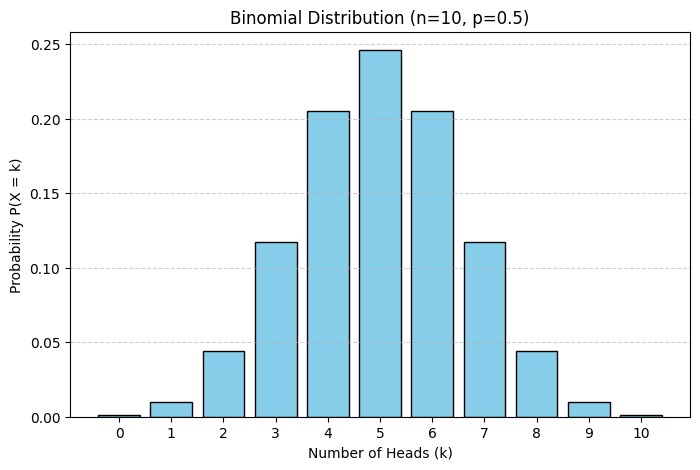

In [5]:
# Step 7: Visualize the Binomial distribution
plt.figure(figsize=(8, 5))
plt.bar(k_values, binom_pmf, color="skyblue", edgecolor="black")
plt.title("Binomial Distribution (n=10, p=0.5)")
plt.xlabel("Number of Heads (k)")
plt.ylabel("Probability P(X = k)")
plt.xticks(k_values)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

**Effect of changing `p`:** Let us see how the shape changes for different success probabilities.

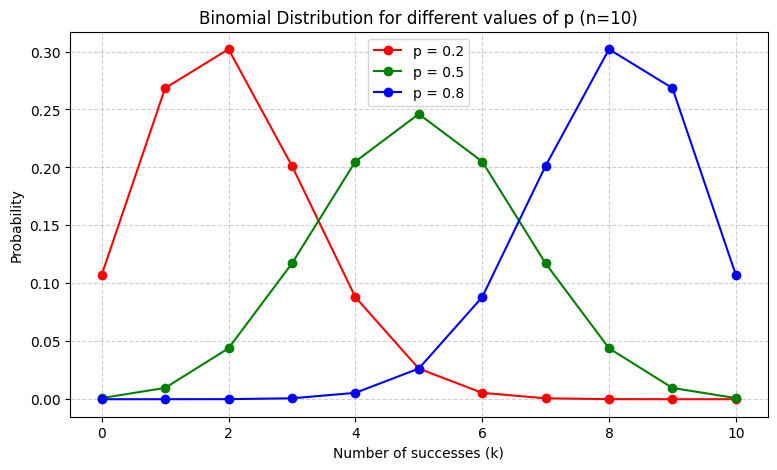

In [6]:
plt.figure(figsize=(9, 5))
for p_val, color in zip([0.2, 0.5, 0.8], ["red", "green", "blue"]):
    plt.plot(k_values, stats.binom.pmf(k_values, n, p_val),
             marker="o", color=color, label=f"p = {p_val}")

plt.title("Binomial Distribution for different values of p (n=10)")
plt.xlabel("Number of successes (k)")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Part B: Poisson Distribution

**Problem:** A help-desk receives on average **4 calls per hour**. What is the probability of receiving exactly 6 calls in an hour? Show the probabilities for 0 to 15 calls.

In [7]:
# Step 8: Set the parameter
lam = 4     # average number of events per interval (lambda)

# Step 9: Possible number of events (0 to 15)
x_values = np.arange(0, 16)

# Step 10: Compute probabilities
poisson_pmf = stats.poisson.pmf(x_values, lam)

print("Calls (x)  ->  Probability P(X = x)")
print("-" * 35)
for x, prob in zip(x_values, poisson_pmf):
    print(f"   {x:2d}      ->      {prob:.4f}")

Calls (x)  ->  Probability P(X = x)
-----------------------------------
    0      ->      0.0183
    1      ->      0.0733
    2      ->      0.1465
    3      ->      0.1954
    4      ->      0.1954
    5      ->      0.1563
    6      ->      0.1042
    7      ->      0.0595
    8      ->      0.0298
    9      ->      0.0132
   10      ->      0.0053
   11      ->      0.0019
   12      ->      0.0006
   13      ->      0.0002
   14      ->      0.0001
   15      ->      0.0000


In [8]:
# Step 11: Answer specific questions
print("P(exactly 6 calls)     =", round(stats.poisson.pmf(6, lam), 4))
print("P(at most 2 calls)     =", round(stats.poisson.cdf(2, lam), 4))
print("P(more than 8 calls)   =", round(1 - stats.poisson.cdf(8, lam), 4))

mean, var = stats.poisson.stats(lam)
print("\nMean     =", mean)
print("Variance =", var, "  (for Poisson, mean = variance = lambda)")

P(exactly 6 calls)     = 0.1042
P(at most 2 calls)     = 0.2381
P(more than 8 calls)   = 0.0214

Mean     = 4.0
Variance = 4.0   (for Poisson, mean = variance = lambda)


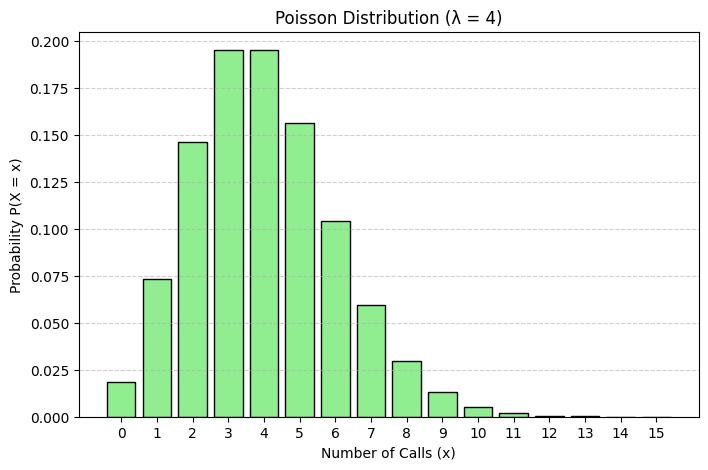

In [9]:
# Step 12: Visualize the Poisson distribution
plt.figure(figsize=(8, 5))
plt.bar(x_values, poisson_pmf, color="lightgreen", edgecolor="black")
plt.title("Poisson Distribution (λ = 4)")
plt.xlabel("Number of Calls (x)")
plt.ylabel("Probability P(X = x)")
plt.xticks(x_values)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

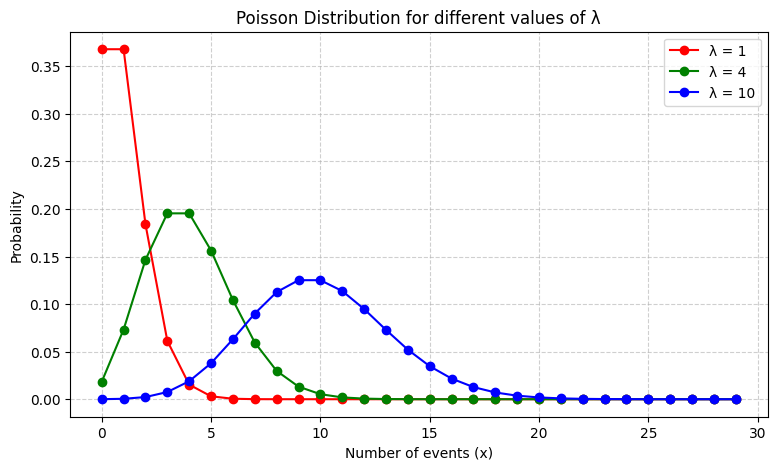

In [10]:
# Effect of changing lambda
x_wide = np.arange(0, 30)

plt.figure(figsize=(9, 5))
for l, color in zip([1, 4, 10], ["red", "green", "blue"]):
    plt.plot(x_wide, stats.poisson.pmf(x_wide, l),
             marker="o", color=color, label=f"λ = {l}")

plt.title("Poisson Distribution for different values of λ")
plt.xlabel("Number of events (x)")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Part C: Binomial vs Poisson (side by side)

When `n` is large and `p` is small, the Binomial distribution becomes very close to the Poisson distribution with λ = n × p.

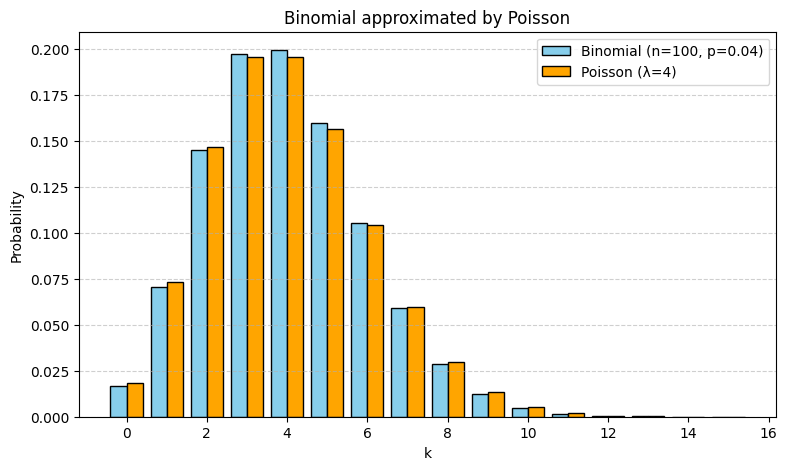

In [11]:
n_big, p_small = 100, 0.04          # n*p = 4  -> lambda = 4
x = np.arange(0, 16)

plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, stats.binom.pmf(x, n_big, p_small), width=0.4,
        label="Binomial (n=100, p=0.04)", color="skyblue", edgecolor="black")
plt.bar(x + 0.2, stats.poisson.pmf(x, n_big * p_small), width=0.4,
        label="Poisson (λ=4)", color="orange", edgecolor="black")

plt.title("Binomial approximated by Poisson")
plt.xlabel("k")
plt.ylabel("Probability")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

## Conclusion

- The **Binomial distribution** was computed and plotted for a coin-toss experiment (n = 10, p = 0.5). It is symmetric when p = 0.5 and skewed when p is different.
- The **Poisson distribution** was computed and plotted for call arrivals (λ = 4). Its mean and variance are both equal to λ.
- For large `n` and small `p`, the Binomial distribution closely matches the Poisson distribution.
- SciPy's `stats.binom` and `stats.poisson` make it easy to calculate `pmf`, `cdf`, mean and variance, and Matplotlib helps us visualize them.